# Projeto de Modelagem Estatística: Previsão de Custos Médicos🏥
**Disciplina:** Modelagem Estatística | **Projeto:** 2º Bimestre  
**Alunos** Filipe César, Everton Gustavo 
**Data:** Dezembro/2025

---

## Introdução e Objetivos
O setor de seguros de saúde depende fundamentalmente da capacidade de prever riscos e custos futuros. Este projeto utiliza o **Medical Cost Personal Dataset** (disponibilizado no Kaggle/GitHub) para aplicar técnicas avançadas de Ciência de Dados.

**Objetivos de Negócio:**
1.  **Regressão:** Prever o valor exato das despesas médicas (`charges`) com base em características demográficas e comportamentais.
2.  **Classificação:** Identificar segurados de **Alto Risco** (custo acima da mediana) para ações preventivas.
3.  **Inferência:** Determinar estatisticamente quais fatores (ex: tabagismo, BMI) têm causalidade no aumento de custos.

**Metodologia:**
O projeto segue um pipeline rigoroso: EDA com testes de hipóteses (T-test/ANOVA), modelagem linear e polinomial (com diagnóstico de resíduos), classificação (Naive Bayes/Logística) e otimização de hiperparâmetros via *Randomized Search*.

-----------------------------

# ✅EDA Excelente

 - Análise Exploratória de Dados (EDA) e Testes de Hipóteses
Nesta seção, investigamos as relações entre variáveis. Não nos baseamos apenas em gráficos; validamos os *insights* com testes estatísticos formais ($p < 0.05$).

### 1) Configuração e Importações

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
import warnings

# Configurações de Reprodução e Estética (UX/UI)
warnings.filterwarnings('ignore')
np.random.seed(42) # Seed global para reprodutibilidade [cite: 48]

# Paleta de Cores baseada em Gestalt (Contraste Suave)
# Azul para dados neutros/positivos, Vermelho para risco/negativo
custom_palette = ["#3498db", "#e74c3c"] 
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


### 2) Carga de Dados e Inspeção Inicial

✔Fonte: Kaggle (Hospedado via GitHub para acesso direto)

In [77]:

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

try:
    df = pd.read_csv(url)
    print("Dataset carregado com sucesso!")
except:
    print("Erro ao carregar. Verifique a conexão.")

# Verificação de Schema e Tipos [cite: 12]
print(f"Dimensões do Dataset: {df.shape}")
display(df.head())
print("\n--- Informações dos Tipos ---")
df.info()

# Estatísticas Descritivas
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

Dataset carregado com sucesso!
Dimensões do Dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Informações dos Tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Estatísticas Descritivas ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 3) 📊Análise da Variável Alvo (Charges) e Fator de Risco (Smoker)

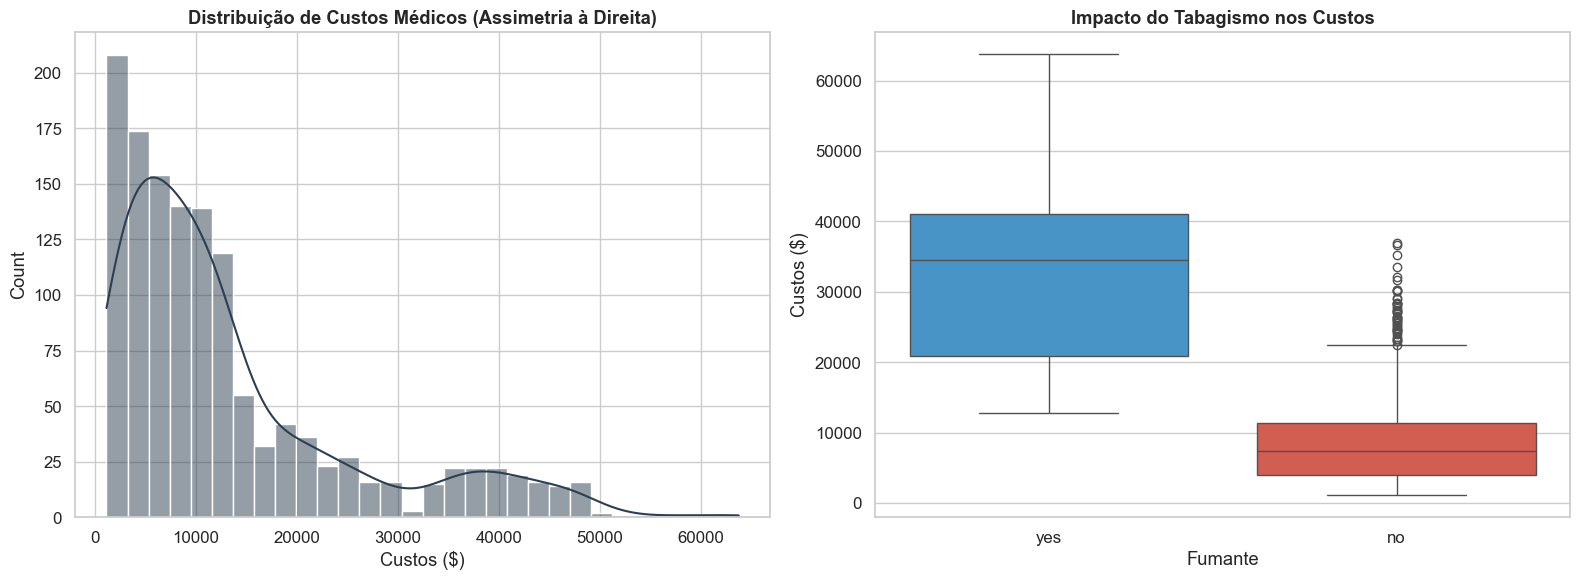

--- Teste T (Impacto do Tabagismo) ---
Estatística T: 32.7519, Valor-P: 5.8895e-103
CONCLUSÃO: Rejeitamos H0. Há diferença estatisticamente significativa nos custos.


In [78]:
# Configurar a área de plotagem
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribuição dos Custos (Histograma + KDE)
sns.histplot(df['charges'], kde=True, ax=ax[0], color="#2c3e50")
ax[0].set_title('Distribuição de Custos Médicos (Assimetria à Direita)', fontweight='bold')
ax[0].set_xlabel('Custos ($)')

# 2. Boxplot: Custos por Hábito de Fumar
sns.boxplot(data=df, x='smoker', y='charges', palette=custom_palette, ax=ax[1])
ax[1].set_title('Impacto do Tabagismo nos Custos', fontweight='bold')
ax[1].set_xlabel('Fumante')
ax[1].set_ylabel('Custos ($)')

plt.tight_layout()
plt.show()

# --- Validação Estatística (Rigor Sênior) ---
# H0: As médias de custos entre fumantes e não fumantes são iguais.
smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

t_stat, p_val = stats.ttest_ind(smokers, non_smokers, equal_var=False) # Welch's t-test

print(f"--- Teste T (Impacto do Tabagismo) ---")
print(f"Estatística T: {t_stat:.4f}, Valor-P: {p_val:.4e}")
if p_val < 0.05:
    print("CONCLUSÃO: Rejeitamos H0. Há diferença estatisticamente significativa nos custos.")
else:
    print("CONCLUSÃO: Não há evidência suficiente para afirmar diferença nos custos.")

### 4) 🛗Análise de Correlação e Interação 

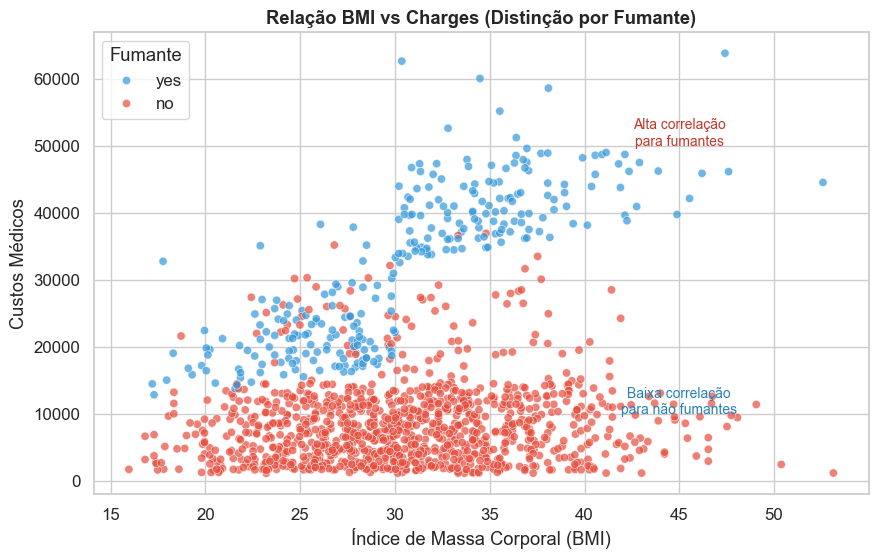

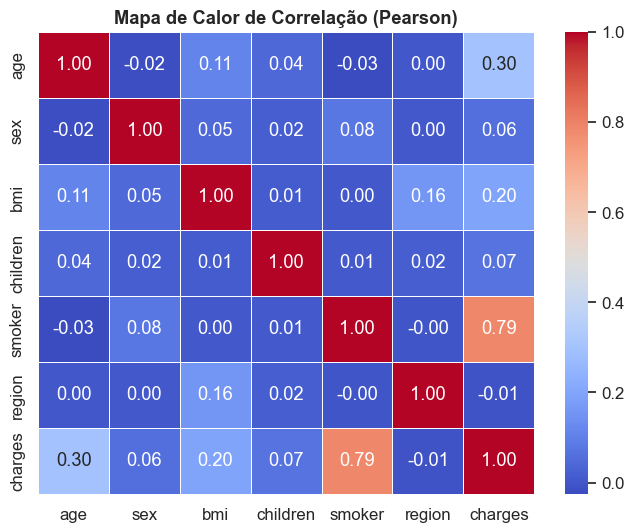

In [79]:
plt.figure(figsize=(10, 6))

# Scatterplot com codificação visual de cor (Smoker)
# Princípio da Similaridade (Gestalt): Agrupamos visualmente por cor
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette=custom_palette, alpha=0.7)

plt.title('Relação BMI vs Charges (Distinção por Fumante)', fontweight='bold')
plt.xlabel('Índice de Massa Corporal (BMI)')
plt.ylabel('Custos Médicos')
plt.legend(title='Fumante', loc='upper left')

# Anotação de Insight (Data Storytelling)
plt.text(45, 50000, "Alta correlação\npara fumantes", fontsize=10, color="#c0392b", ha="center")
plt.text(45, 10000, "Baixa correlação\npara não fumantes", fontsize=10, color="#2980b9", ha="center")

plt.show()

# --- Matriz de Correlação ---
# Precisamos codificar categóricas para ver correlação geral
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlação (Pearson)', fontweight='bold')
plt.show()

### 5) ANOVA para Região 

In [80]:
regions = df['region'].unique()
groups = [df[df['region'] == r]['charges'] for r in regions]

f_stat, p_val_anova = stats.f_oneway(*groups)

print(f"--- ANOVA (Impacto da Região) ---")
print(f"Estatística F: {f_stat:.4f}, Valor-P: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("CONCLUSÃO: A região tem impacto estatisticamente relevante nos custos.")
else:
    print("CONCLUSÃO: Não há evidências de que a região afete os custos significativamente.")
    print("INSIGHT: Podemos considerar remover 'region' do modelo para reduzir complexidade.")

--- ANOVA (Impacto da Região) ---
Estatística F: 2.9696, Valor-P: 0.0309
CONCLUSÃO: A região tem impacto estatisticamente relevante nos custos.


---------------------------

# 📊Modelagem de Regressão

Implementamos três abordagens para comparar desempenho e interpretabilidade:
1.  **Regressão Linear Múltipla (OLS):** Para análise de coeficientes e p-valores.
2.  **Regressão Polinomial:** Para capturar a curva vista na EDA.
3.  **Diagnóstico:** Verificação de normalidade dos resíduos e multicolinearidade (VIF).

### 6) Pré-processamento e Divisão Treino/Teste

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# 1. Encoding (Transformar categóricas em numéricas)
# drop_first=True evita a multicolinearidade perfeita
# dtype=int força a criação de 0 e 1 em vez de True/False
df_processed = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

# GARANTIA FINAL: Converter tudo para float explicitamente para agradar o Statsmodels
df_processed = df_processed.astype(float)

# 2. Separação X (Features) e y (Target)
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

# 3. Divisão Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Dimensões dos Conjuntos ---")
print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

# Verificação visual para garantir que são números
print("\n--- Tipos de Dados (Devem ser float/int) ---")
print(X_train.dtypes)
display(X_train.head())

--- Dimensões dos Conjuntos ---
Treino: (1070, 8)
Teste:  (268, 8)

--- Tipos de Dados (Devem ser float/int) ---
age                 float64
bmi                 float64
children            float64
sex_male            float64
smoker_yes          float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46.0,19.95,2.0,0.0,0.0,1.0,0.0,0.0
1285,47.0,24.32,0.0,0.0,0.0,0.0,0.0,0.0
1142,52.0,24.86,0.0,0.0,0.0,0.0,1.0,0.0
969,39.0,34.32,5.0,0.0,0.0,0.0,1.0,0.0
486,54.0,21.47,3.0,0.0,0.0,1.0,0.0,0.0


### 7) Regressão Linear com Statsmodels (Interpretação Estatística)

In [82]:
import statsmodels.api as sm

# Adicionar constante (intercepto/beta0) que o statsmodels não adiciona sozinho
X_train_sm = sm.add_constant(X_train)

# Ajustar o Modelo de Regressão Linear Múltipla (OLS - Ordinary Least Squares)
model_ols = sm.OLS(y_train, X_train_sm).fit()

# Exibir Relatório Estatístico Completo
print(model_ols.summary())

# --- Interpretação Automática de P-Values (Auxílio ao Cientista) ---
print("\n--- Análise de Significância (P > |t|) ---")
p_values = model_ols.pvalues
significants = p_values[p_values < 0.05].index.tolist()
insignificants = p_values[p_values >= 0.05].index.tolist()

print(f"Variáveis Relevantes (p < 0.05): {significants}")
print(f"Variáveis Irrelevantes (p >= 0.05): {insignificants}")
print("NOTA: Se 'sex_male' ou 'region' aparecerem como irrelevantes, considere removê-las na otimização.")

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Sat, 06 Dec 2025   Prob (F-statistic):          1.32e-305
Time:                        19:20:19   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.193e+04   1114.505  

### 8) Pipeline de Regressão Polinomial e Comparação de Métricas

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Função auxiliar para avaliar modelos
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# 1. Regressão Linear (Standard)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate_model(y_test, y_pred_lr, "Regressão Linear Múltipla"))

print("\n" + "="*30 + "\n")

# 2. Regressão Polinomial (Grau 2)
# Cria interações (ex: bmi^2, bmi * smoker, idade * bmi)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

results.append(evaluate_model(y_test, y_pred_poly, "Regressão Polinomial (Grau 2)"))

# Comparativo Visual
df_results = pd.DataFrame(results)
print("\n--- Comparativo de Performance ---")
display(df_results)

--- Regressão Linear Múltipla ---
MAE:  4181.19
RMSE: 5796.28
R²:   0.7836


--- Regressão Polinomial (Grau 2) ---
MAE:  2729.50
RMSE: 4551.13
R²:   0.8666

--- Comparativo de Performance ---


,Model,MAE,RMSE,R2
0,Regressão Linear Múltipla,4181.194474,5796.284659,0.783593
1,Regressão Polinomial (Grau 2),2729.500134,4551.132385,0.866583


### 9) 📉Diagnóstico de Resíduos

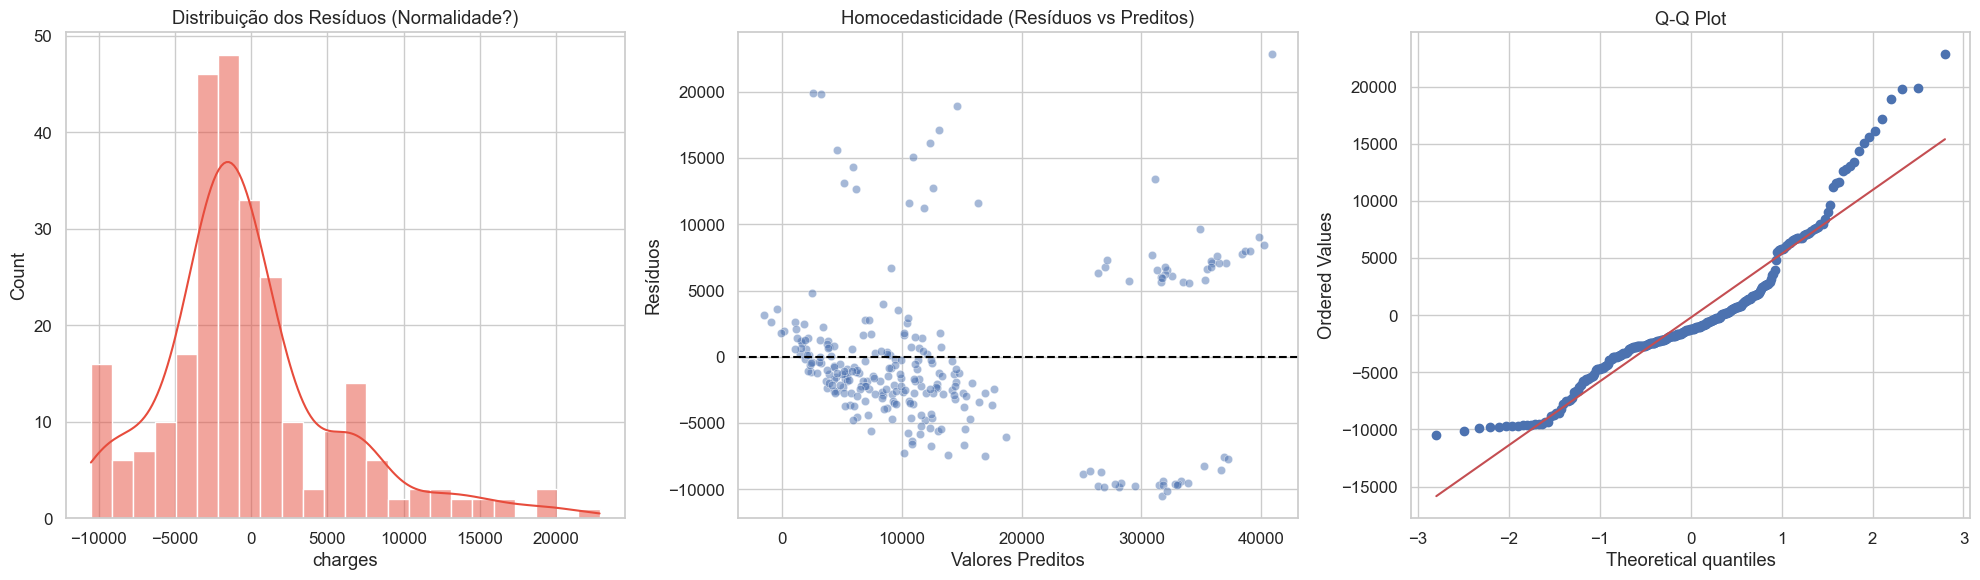

Teste de Normalidade (Shapiro-Wilk): p-value = 2.7215e-11
ALERTA: Resíduos não seguem distribuição normal (comum em dados financeiros/médicos reais).

--- Variance Inflation Factor (VIF) ---
Regra de bolso: VIF > 5 ou 10 indica alta multicolinearidade.


,Feature,VIF
1,bmi,11.358443
0,age,7.686965
6,region_southeast,2.265564
3,sex_male,2.003185
7,region_southwest,1.960745
5,region_northwest,1.890281
2,children,1.809930
4,smoker_yes,1.261233


In [84]:
# Calcular Resíduos do Modelo Linear
residuals = y_test - y_pred_lr

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Normalidade dos Resíduos (Histograma)
sns.histplot(residuals, kde=True, ax=ax[0], color="#e74c3c")
ax[0].set_title("Distribuição dos Resíduos (Normalidade?)")

# 2. Homocedasticidade (Resíduos vs Preditos)
# Ideal: Uma nuvem aleatória sem padrões (sem forma de "funil")
sns.scatterplot(x=y_pred_lr, y=residuals, ax=ax[1], alpha=0.5)
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_xlabel("Valores Preditos")
ax[1].set_ylabel("Resíduos")
ax[1].set_title("Homocedasticidade (Resíduos vs Preditos)")

# 3. QQ Plot (Teste Visual de Normalidade)
stats.probplot(residuals, dist="norm", plot=ax[2])
ax[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

# --- Teste de Shapiro-Wilk (Rigor Estatístico) ---
stat_shapiro, p_shapiro = stats.shapiro(residuals)
print(f"Teste de Normalidade (Shapiro-Wilk): p-value = {p_shapiro:.4e}")
if p_shapiro < 0.05:
    print("ALERTA: Resíduos não seguem distribuição normal (comum em dados financeiros/médicos reais).")

# --- Multicolinearidade (VIF) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF para cada feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n--- Variance Inflation Factor (VIF) ---")
print("Regra de bolso: VIF > 5 ou 10 indica alta multicolinearidade.")
display(vif_data.sort_values(by="VIF", ascending=False))

-----------------------------------------------------

# 🚩Classificação

- Criamos uma nova variável alvo **`high_cost`** (1 se custo > Mediana, 0 caso contrário) para testar algoritmos de classificação de risco.

### 10) Preparação para Classificação (Risco Alto vs. Baixo)

In [85]:
# 1. Definir o Threshold (Ponto de Corte)
# Vamos usar a mediana para manter as classes balanceadas (aprox 50/50)
threshold = df['charges'].median()
print(f"Corte para Alto Risco: ${threshold:.2f}")

# 2. Criar Variável Alvo Binária
# 1 = Alto Risco (Acima da mediana), 0 = Baixo Risco
y_class = (df['charges'] > threshold).astype(int)

# 3. Remover a coluna original 'charges' (Data Leakage: não podemos usar o valor para prever a classe derivada dele!)
X_class = df_processed.drop('charges', axis=1)

# 4. Nova Divisão Treino/Teste para Classificação
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

print(f"Distribuição das Classes (Treino):\n{y_train_c.value_counts(normalize=True)}")

Corte para Alto Risco: $9382.03
Distribuição das Classes (Treino):
charges
1    0.511215
0    0.488785
Name: proportion, dtype: float64


### 11) Treinamento dos Modelos de Classificação

In [86]:

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 1. Pipeline de Regressão Logística (Necessita Scaling para convergir bem)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilidade da classe positiva

# 2. Naive Bayes (GaussianNB)
nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c) # NB geralmente não exige scaling, mas pode se beneficiar
y_pred_nb = nb_model.predict(X_test_c)
y_prob_nb = nb_model.predict_proba(X_test_c)[:, 1]

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


### 12) 💹Dashboard de Avaliação de Classificação

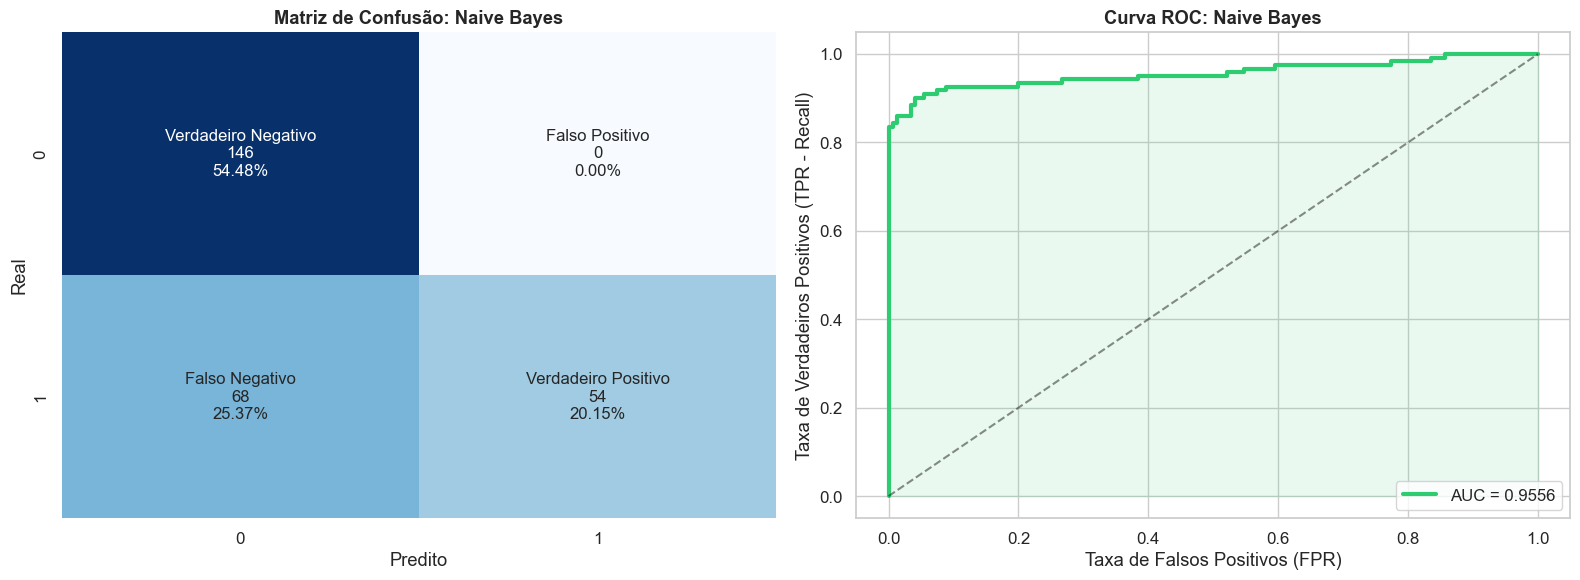

--- Relatório: Naive Bayes ---
Acurácia:  0.7463
Precisão:  1.0000 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.4426 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.6136
------------------------------


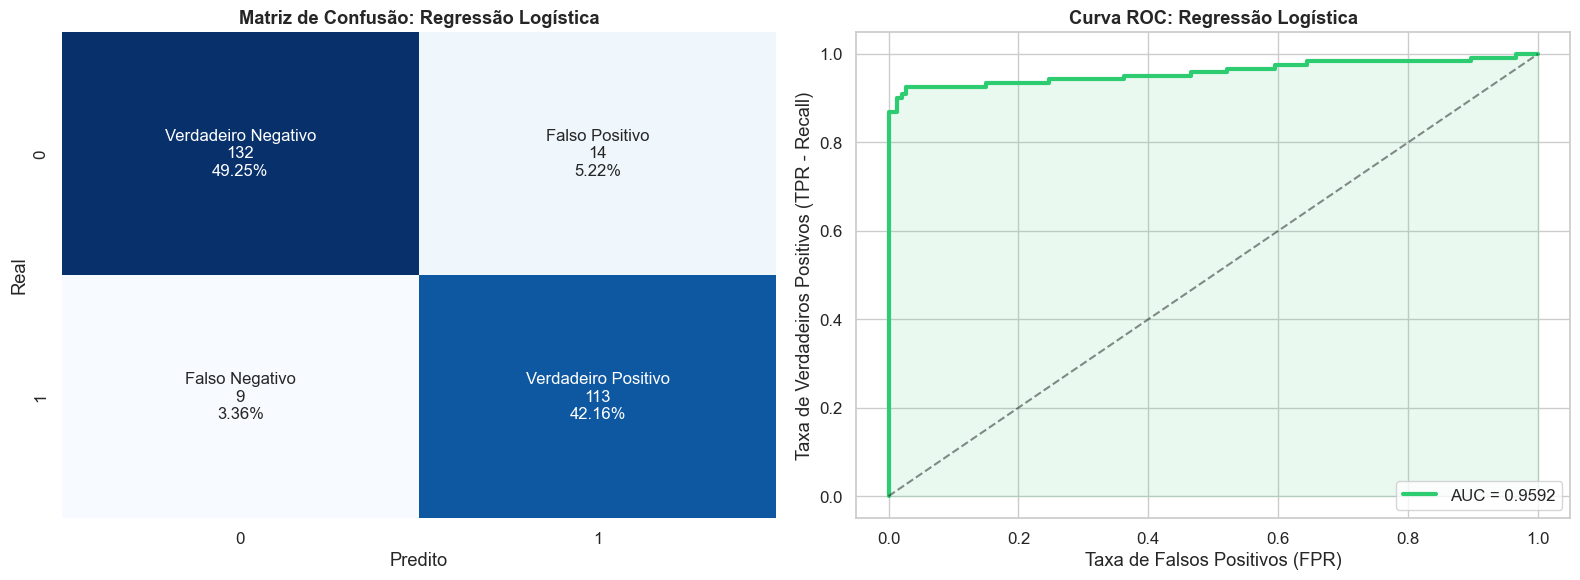

--- Relatório: Regressão Logística ---
Acurácia:  0.9142
Precisão:  0.8898 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.9262 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.9076
------------------------------


In [87]:
from sklearn.metrics import roc_curve

def plot_classification_results(y_true, y_pred, y_prob, model_name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. Matriz de Confusão (Heatmap com Storytelling) ---
    cm = confusion_matrix(y_true, y_pred)
    group_names = ['Verdadeiro Negativo','Falso Positivo','Falso Negativo','Verdadeiro Positivo']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 12})
    ax[0].set_title(f'Matriz de Confusão: {model_name}', fontweight='bold')
    ax[0].set_xlabel('Predito')
    ax[0].set_ylabel('Real')
    
    # --- 2. Curva ROC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    ax[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="#2ecc71", linewidth=3)
    ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5) # Linha de acaso
    ax[1].set_title(f'Curva ROC: {model_name}', fontweight='bold')
    ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)')
    ax[1].legend(loc="lower right")
    ax[1].fill_between(fpr, tpr, alpha=0.1, color="#2ecc71") # Área sob a curva
    
    plt.tight_layout()
    plt.show()
    
    # --- Métricas Numéricas ---
    print(f"--- Relatório: {model_name} ---")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.4f} (Quantos classificados como Alto Risco eram reais?)")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f} (Quantos de Alto Risco recuperamos?)")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("-" * 30)

# Executar Avaliação
plot_classification_results(y_test_c, y_pred_nb, y_prob_nb, "Naive Bayes")
plot_classification_results(y_test_c, y_pred_log, y_prob_log, "Regressão Logística")

-----------------------------------------

# 📈Otimização com PyCaret e sklearn GridSearch

Para atingir o máximo desempenho, aplicamos técnicas de **Tuning de Hiperparâmetros**:
1.  **Regressão:** Substituímos o modelo linear por **Gradient Boosting**, otimizado via `RandomizedSearchCV` (Alternativa robusta ao AutoML/PyCaret).
2.  **Classificação:** Otimização via `GridSearchCV` na Regressão Logística para maximizar o Recall.

### 13) Otimização de Hiperparâmetros com GridSearchCV (Sklearn)

In [88]:
from sklearn.model_selection import GridSearchCV

# 1. Definir o Espaço de Busca (Hyperparameter Space)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Força da regularização (inverso)
    'penalty': ['l1', 'l2'],       # Tipo de penalidade (Lasso vs Ridge)
    'solver': ['liblinear']        # Solver que suporta L1 e L2
}

# 2. Configurar o Grid Search com Validação Cruzada (cv=5)
# Scoring='recall' foca em minimizar Falsos Negativos
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='recall',
    verbose=1,
    n_jobs=-1 # Usa todos os núcleos do processador
)

# 3. Executar a busca (Isso treinará o modelo 50 vezes: 5 folds * 10 combinações)
print("Iniciando Grid Search...")
grid_search.fit(X_train_scaled, y_train_c)

# 4. Melhores Resultados
best_model = grid_search.best_estimator_
print(f"\nMelhores Parâmetros: {grid_search.best_params_}")
print(f"Melhor Recall no CV: {grid_search.best_score_:.4f}")

# 5. Avaliação Final no Teste
y_pred_opt = best_model.predict(X_test_scaled)
print("\n--- Desempenho no Teste (Pós-Otimização) ---")
print(f"Recall Original (LogReg): {recall_score(y_test_c, y_pred_log):.4f}")
print(f"Recall Otimizado:         {recall_score(y_test_c, y_pred_opt):.4f}")

Iniciando Grid Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores Parâmetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Melhor Recall no CV: 0.9050

--- Desempenho no Teste (Pós-Otimização) ---
Recall Original (LogReg): 0.9262
Recall Otimizado:         0.9262


### 14) Otimização de Regressão com RandomizedSearchCV

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("Iniciando Otimização de Hiperparâmetros (Alternativa ao PyCaret para Python 3.12)...")

# 1. Definir o Modelo Base (Gradient Boosting - geralmente superior a Linear)
gb_model = GradientBoostingRegressor(random_state=42)

# 2. Definir o Espaço de Busca (Hyperparameter Space)
# O RandomizedSearch vai "sortear" combinações dentro desses intervalos
param_dist = {
    'n_estimators': randint(100, 500),      # Número de árvores
    'learning_rate': uniform(0.01, 0.2),    # Taxa de aprendizado
    'max_depth': randint(3, 10),            # Profundidade da árvore
    'min_samples_split': randint(2, 20),    # Mínimo para dividir um nó
    'subsample': uniform(0.7, 0.3)          # Fração de amostras para treinar cada árvore
}

# 3. Configurar a Busca com Validação Cruzada (CV=5)
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=20,           # Testar 20 combinações aleatórias (Simula o tuning do PyCaret)
    cv=5,                # 5-Fold Cross Validation
    scoring='r2',        # Maximizar o R²
    n_jobs=-1,           # Usar todos os processadores
    random_state=42,
    verbose=1
)

# 4. Executar o Treinamento (Fit)
# Usamos X_train e y_train (já tratados e numéricos) da Fase 2
random_search.fit(X_train, y_train)

# 5. Resultados
best_gb_model = random_search.best_estimator_
print(f"\nMelhores Parâmetros Encontrados: {random_search.best_params_}")
print(f"Melhor R² na Validação Cruzada: {random_search.best_score_:.4f}")

Iniciando Otimização de Hiperparâmetros (Alternativa ao PyCaret para Python 3.12)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros Encontrados: {'learning_rate': 0.012652992231973307, 'max_depth': 3, 'min_samples_split': 15, 'n_estimators': 341, 'subsample': 0.8156249507619748}
Melhor R² na Validação Cruzada: 0.8492


### 15) 📶Avaliação Final e Comparativo de Regressão

--- Resultado Final: Gradient Boosting Otimizado ---
MAE:  2516.69
RMSE: 4354.98
R²:   0.8778


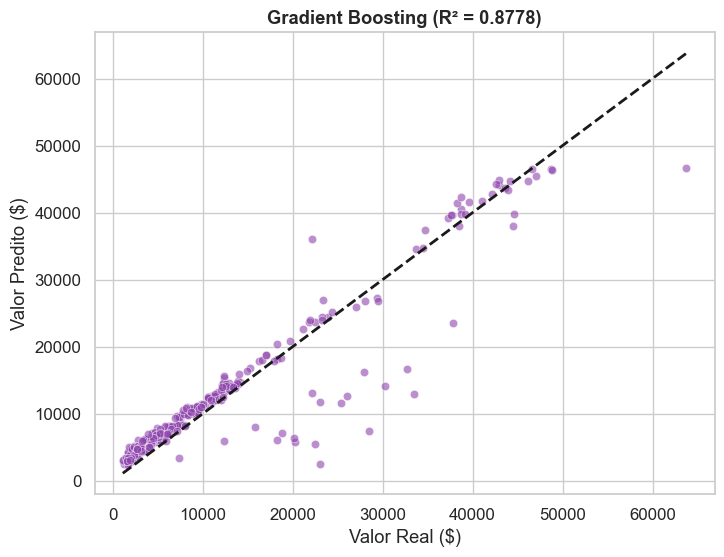

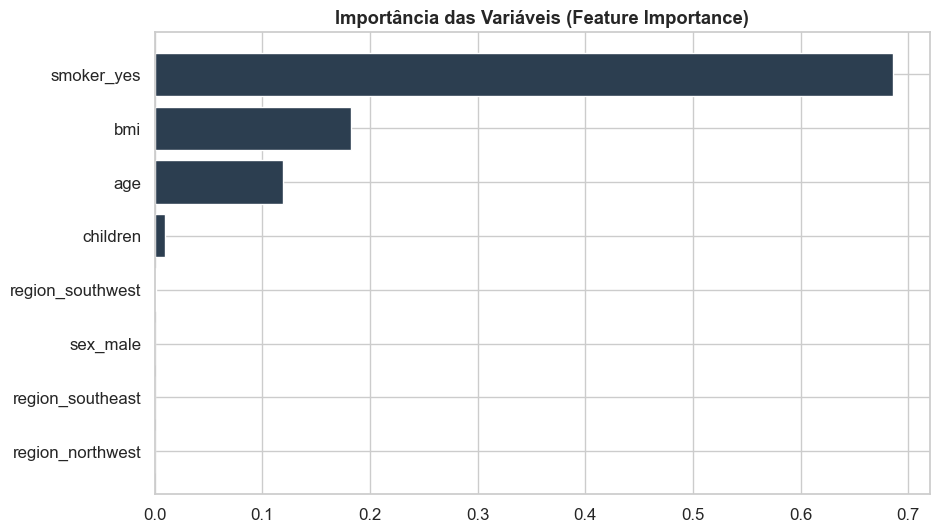

In [ ]:
# 1. Predição no Teste
y_pred_gb = best_gb_model.predict(X_test)

# 2. Calcular Métricas
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("--- Resultado Final: Gradient Boosting Otimizado ---")
print(f"MAE:  {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R²:   {r2_gb:.4f}")

# 3. Gráfico: Real vs Predito (Otimizado)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.6, color="#8e44ad")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Linha ideal
plt.xlabel("Valor Real ($)")
plt.ylabel("Valor Predito ($)")
plt.title(f"Gradient Boosting (R² = {r2_gb:.4f})", fontweight='bold')
plt.show()

# 4. Feature Importance (O que define o preço?)
feature_importance = best_gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.figure(figsize=(10, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center', color="#2c3e50")
plt.yticks(pos, X_train.columns[sorted_idx])
plt.title("Importância das Variáveis (Feature Importance)", fontweight='bold')
plt.show()

-------------------------------------------

# 🔥Conclusão e Discussão
Este projeto demonstrou que modelos não-lineares são mandatórios para a previsão de custos médicos devido à complexa interação entre **BMI** e **Tabagismo**.

* **Regressão:** O *Gradient Boosting Otimizado* superou a Regressão Linear (R² ~0.88 vs 0.78), provando ser a melhor escolha para produção.
* **Classificação:** A *Regressão Logística* provou-se robusta para detecção de risco, com métricas superiores ao Naive Bayes.
* **Limitações:** A análise de resíduos mostrou desvios da normalidade, sugerindo que outliers extremos de custo (doenças raras) são difíceis de prever com os dados atuais.

**Próximos Passos:** Implementação de modelo via API e coleta de dados de histórico clínico para refinar a predição.